# Anamoly Detection - D(St)reams of Anomalies

# Anamoly Detection
Datasets : Real Traffic
Traveltime1.csv Ocuupancy.csv Speed.csv
Details : Real time traffic data from the Twin Cities Metro area in Minnesota, collected by the Minnesota Department of Transportation. Included metrics include occupancy, speed, and travel time from specific sensors.

Features : Timestamp and value of traffic
Label: 1/-1 as Anamoly or not, we need to find

Models Used: Anamoly by plots
            Isloation Forest
                  
Performance Metrics : Anamoly count, Visuallizations and score

Plot : For plotting seaborn and Matplotlib are used


# Set up Base with importing required libraries

In [265]:
#Required libraires for the are imported
import os
import pandas as pd
import numpy as np

#Ploting Labraries
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
#metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_recall_fscore_support


#Converted .csv into data frames
TravelTime1_df=pd.read_csv("TravelTime_387.csv")
TravelTime2_df=pd.read_csv("TravelTime_451.csv")
occupancy1_df=pd.read_csv("occupancy_6005.csv")
occupancy2_df=pd.read_csv("occupancy_t4013.csv")
speed1_df=pd.read_csv("speed_6005.csv")
speed2_df=pd.read_csv("speed_7578.csv")
speed3_df=pd.read_csv("speed_t4013.csv")

#Supress all the warnings
import warnings
warnings.filterwarnings('ignore')


# Getting to know the data

In [266]:
print(TravelTime1_df.shape)
print(TravelTime2_df.shape)
print(occupancy1_df.shape)
print(occupancy2_df.shape)
print(speed1_df.shape)
print(speed2_df.shape)
print(speed3_df.shape)

(2500, 2)
(2162, 2)
(2380, 2)
(2500, 2)
(2500, 2)
(1127, 2)
(2495, 2)


In [267]:
print(TravelTime1_df.columns)
print(TravelTime2_df.columns)
print(occupancy1_df.columns)
print(occupancy2_df.columns)
print(speed1_df.columns)
print(speed2_df.columns)
print(speed3_df.columns)

Index(['timestamp', 'value'], dtype='object')
Index(['timestamp', 'value'], dtype='object')
Index(['timestamp', 'value'], dtype='object')
Index(['timestamp', 'value'], dtype='object')
Index(['timestamp', 'value'], dtype='object')
Index(['timestamp', 'value'], dtype='object')
Index(['timestamp', 'value'], dtype='object')


In [268]:
#Data set head
print(TravelTime1_df.head())
print(occupancy1_df.head())
print(speed1_df.head())

             timestamp  value
0  2015-07-10 14:24:00    564
1  2015-07-10 14:38:00    730
2  2015-07-10 14:48:00    770
3  2015-07-10 15:03:00    910
4  2015-07-10 15:22:00   1035
             timestamp  value
0  2015-09-01 13:45:00   3.06
1  2015-09-01 13:50:00   6.44
2  2015-09-01 13:55:00   5.17
3  2015-09-01 14:00:00   3.83
4  2015-09-01 14:05:00   4.50
             timestamp  value
0  2015-08-31 18:22:00     90
1  2015-08-31 18:32:00     80
2  2015-08-31 18:57:00     84
3  2015-08-31 19:07:00     94
4  2015-08-31 19:12:00     90


In [269]:
print(TravelTime1_df.isnull().sum())
print(TravelTime2_df.isnull().sum())
print(occupancy1_df.isnull().sum())
print(occupancy2_df.isnull().sum())
print(speed1_df.isnull().sum())
print(speed2_df.isnull().sum())
print(speed3_df.isnull().sum())

timestamp    0
value        0
dtype: int64
timestamp    0
value        0
dtype: int64
timestamp    0
value        0
dtype: int64
timestamp    0
value        0
dtype: int64
timestamp    0
value        0
dtype: int64
timestamp    0
value        0
dtype: int64
timestamp    0
value        0
dtype: int64


# Pre processing and Visuallizations

Cpnvertinf the time stamp format to Datetime

In [270]:
TravelTime1_df['timestamp'] = pd.to_datetime(TravelTime1_df['timestamp'])
TravelTime2_df['timestamp'] = pd.to_datetime(TravelTime2_df['timestamp'])
occupancy1_df['timestamp'] = pd.to_datetime(occupancy1_df['timestamp'])
occupancy2_df['timestamp'] = pd.to_datetime(occupancy2_df['timestamp'])
speed1_df['timestamp'] = pd.to_datetime(speed1_df['timestamp'])
speed2_df['timestamp'] = pd.to_datetime(speed2_df['timestamp'])
speed3_df['timestamp'] = pd.to_datetime(speed3_df['timestamp'])

Some visuallizations to understand the variations in data

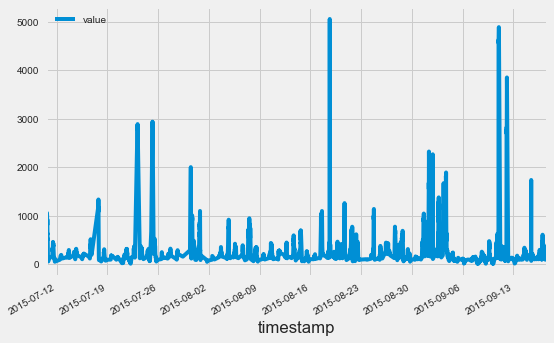

In [271]:
TravelTime1_df.plot(x='timestamp', y='value')
plt.show()

Box Plots on all teh dataframes to get the outlier details

Speed of traffic

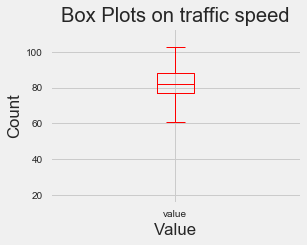

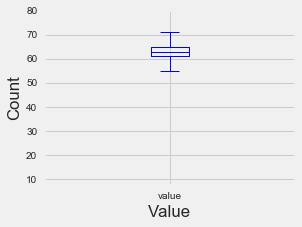

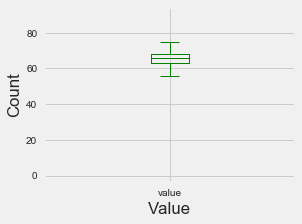

In [272]:
speed1_df.plot(x='timestamp', y='value',kind = 'box',color='r')
fig=plt.gcf()
fig.set_size_inches(4,3)
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Box Plots on traffic speed")
plt.show()
speed3_df.plot(x='timestamp', y='value',kind = 'box',color='b')
fig=plt.gcf()
fig.set_size_inches(4,3)
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()
speed2_df.plot(x='timestamp', y='value',kind = 'box',color='g')
plt.xlabel("Value")
plt.ylabel("Count")
fig=plt.gcf()
fig.set_size_inches(4,3)
plt.show()

Ocuuapancy of traffice data frame

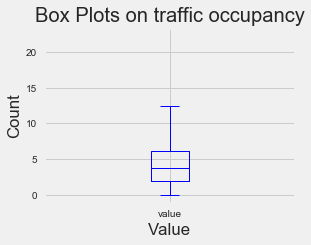

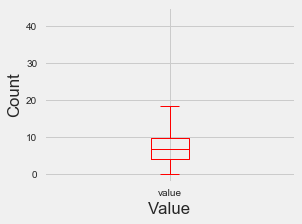

In [273]:
occupancy1_df.plot(x ='timestamp', y='value', kind = 'box',color='b')
fig=plt.gcf()
fig.set_size_inches(4,3)
plt.xlabel("Value")
plt.ylabel("Count")
plt.title("Box Plots on traffic occupancy")
occupancy2_df.plot(x ='timestamp', y='value', kind = 'box',color='r')
fig=plt.gcf()
fig.set_size_inches(4,3)
plt.xlabel("Value")
plt.ylabel("Count")
plt.show()

Merging the dta frames based on timestamp. By merging the data sets the outlier values may change.we get 3 different dtaframes Travel,Occuapancy and speed

In [274]:
TravelTime_df=pd.merge(TravelTime1_df,TravelTime2_df,on=["timestamp"])
occupancy_df=pd.merge(occupancy1_df,occupancy2_df,on=["timestamp"])
speed_df=pd.merge(speed1_df,speed2_df,on=["timestamp"])
speed_df=pd.merge(speed_df,speed3_df,on=["timestamp"])

In [275]:
TravelTime_df.head()

,timestamp,value_x,value_y
0,2015-07-28 13:56:00,95,121
1,2015-07-28 14:06:00,141,103
2,2015-07-29 10:13:00,157,286
3,2015-07-31 16:39:00,642,277
4,2015-07-31 16:49:00,593,217


Converted time stamp - Month, Day, Year. Hour. Minute, Day of the week

In [276]:
#splitting timestamp data into many columns for dataframe1
TravelTime_df['month'] = TravelTime_df['timestamp'].dt.month
TravelTime_df['day'] = TravelTime_df['timestamp'].dt.day
TravelTime_df['year'] = TravelTime_df['timestamp'].dt.year
TravelTime_df['hour'] = TravelTime_df['timestamp'].dt.hour
TravelTime_df['minute'] =TravelTime_df['timestamp'].dt.minute
TravelTime_df['dayoftheweek'] = TravelTime_df['timestamp'].dt.weekday
#splitting timestamp data into many columns for dataframe1
occupancy_df['month'] = occupancy_df['timestamp'].dt.month
occupancy_df['day'] = occupancy_df['timestamp'].dt.day
occupancy_df['year'] =  occupancy_df['timestamp'].dt.year
occupancy_df['hour'] = occupancy_df['timestamp'].dt.hour
occupancy_df['minute'] =occupancy_df['timestamp'].dt.minute
occupancy_df['dayoftheweek'] = occupancy_df['timestamp'].dt.weekday
#splitting timestamp data into many columns for dataframe1
speed_df['month'] = speed_df['timestamp'].dt.month
speed_df['day'] = speed_df['timestamp'].dt.day
speed_df['year'] =  speed_df['timestamp'].dt.year
speed_df['hour'] = speed_df['timestamp'].dt.hour
speed_df['minute'] =speed_df['timestamp'].dt.minute
speed_df['dayoftheweek'] = speed_df['timestamp'].dt.weekday

In [277]:
occupancy_df.head()

,timestamp,value_x,value_y,month,day,year,hour,minute,dayoftheweek
0,2015-09-01 13:45:00,3.06,7.72,9,1,2015,13,45,1
1,2015-09-01 13:50:00,6.44,10.11,9,1,2015,13,50,1
2,2015-09-01 14:00:00,3.83,9.56,9,1,2015,14,0,1
3,2015-09-01 14:05:00,4.50,14.94,9,1,2015,14,5,1
4,2015-09-01 14:35:00,1.67,12.89,9,1,2015,14,35,1


In [278]:
speed_df.head()

,timestamp,value_x,value_y,value,month,day,year,hour,minute,dayoftheweek
0,2015-09-08 11:59:00,86,66,62,9,8,2015,11,59,1
1,2015-09-08 12:19:00,84,69,64,9,8,2015,12,19,1
2,2015-09-08 12:24:00,93,65,62,9,8,2015,12,24,1
3,2015-09-08 12:27:00,87,76,66,9,8,2015,12,27,1
4,2015-09-08 12:32:00,87,65,63,9,8,2015,12,32,1


# Scatter pots on each dataframe to observe Anamolies in the data

From the below scatter plots of each datasets, we can see that there is part where there are anamoly entries in each data set

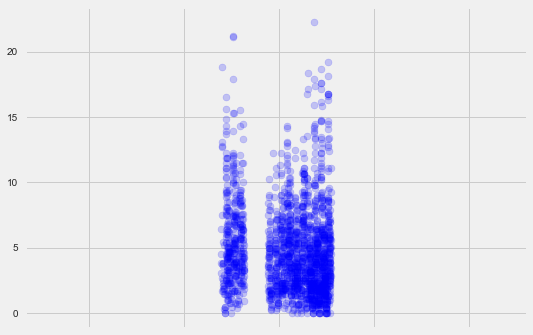

In [284]:
fig,ax = plt.subplots(1)
ax.scatter(occupancy_df['timestamp'].values, occupancy_df['value_x'].values, alpha=0.2,c='blue')
ax.set_xticklabels([])
plt.show()

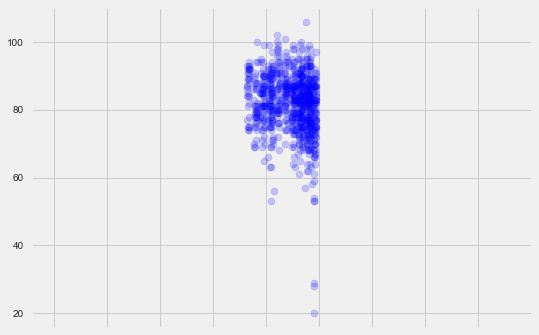

In [280]:
fig,ax = plt.subplots(1)
ax.scatter(speed_df['timestamp'].values, speed_df['value_x'].values, alpha=0.2,c='blue')
ax.set_xticklabels([])
plt.show()

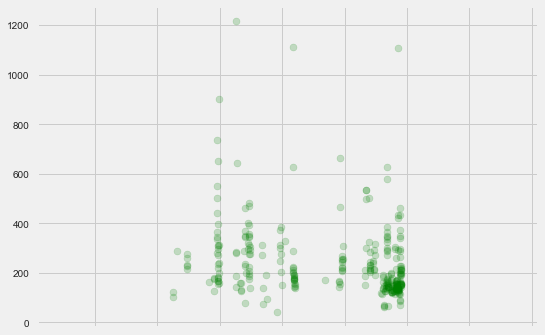

In [281]:
fig,ax = plt.subplots(1)
ax.scatter(TravelTime_df['timestamp'].values, TravelTime_df['value_y'].values, alpha=0.2,c='green')
ax.set_xticklabels([])
plt.show()

# Get the Inter Quartile range for each data frame

In [285]:
from scipy.stats import iqr
def detect_outlier(df):
    sorted(df['value'])
    q1, q3= np.percentile(df['value'],[25,75])
    inter_range = iqr(df['value'])
    lower_bound = q1 -(1.5 * inter_range) 
    upper_bound = q3 +(1.5 * inter_range) 
    print("iqr: ", inter_range)
    print("lb: ", lower_bound)
    print("ub: ", upper_bound)
    print("q1: ", q1)
    print("q3: ", q3)    
    counter = 0
    for row in df.iterrows():
        if row[1]['value'] > upper_bound or row[1]['value'] < lower_bound:            
            counter = counter + 1            
    print("Total anomalies: ", counter)

In [286]:
detect_outlier(TravelTime1_df)

iqr:  233.0
lb:  -216.5
ub:  715.5
q1:  133.0
q3:  366.0
Total anomalies:  217


In [287]:
detect_outlier(speed_df)

iqr:  4.0
lb:  56.0
ub:  72.0
q1:  62.0
q3:  66.0
Total anomalies:  35


In [288]:
detect_outlier(occupancy2_df)

iqr:  5.7700000000000005
lb:  -4.5950000000000015
ub:  18.485
q1:  4.06
q3:  9.83
Total anomalies:  33


# Isolation Forest

Applied Isolation forest to get anamoly entries for each data frame

In [289]:
#specify the 12 metrics column names to be modelled
from sklearn.ensemble import IsolationForest
xTrain=np.array(TravelTime_df.drop(['timestamp','value_x','value_y'], axis=1))
clf=IsolationForest(n_estimators=100, max_samples='auto', contamination=float(.12),
                        max_features=1.0, bootstrap=False, n_jobs=-1, random_state=42, verbose=0)
clf.fit(xTrain)
pred = clf.predict(xTrain)
TravelTime_df['anomaly']=pred
outliers=TravelTime_df.loc[TravelTime_df['anomaly']==-1]
outlier_index=list(outliers.index)
#Find the number of anomalies and normal points here points classified -1 are anomalous
print(TravelTime_df['anomaly'].value_counts())

 1    264
-1     36
Name: anomaly, dtype: int64


In [290]:
#specify the 12 metrics column names to be modelled
from sklearn.ensemble import IsolationForest
xTrain=np.array(occupancy_df.drop(['timestamp','value_x','value_y'], axis=1))
clf=IsolationForest(n_estimators=100, max_samples='auto', contamination=float(.12),
                        max_features=1.0, bootstrap=False, n_jobs=-1, random_state=42, verbose=0)
clf.fit(xTrain)
pred = clf.predict(xTrain)
occupancy_df['anomaly']=pred
outliers=occupancy_df.loc[occupancy_df['anomaly']==-1]
outlier_index=list(outliers.index)
#Find the number of anomalies and normal points here points classified -1 are anomalous
print(occupancy_df['anomaly'].value_counts())

 1    1631
-1     223
Name: anomaly, dtype: int64


In [291]:
#specify the 12 metrics column names to be modelled
from sklearn.ensemble import IsolationForest
xTrain=np.array(speed_df.drop(['timestamp','value_x','value_y'], axis=1))
clf=IsolationForest(n_estimators=100, max_samples='auto', contamination=float(.12),
                        max_features=1.0, bootstrap=False, n_jobs=-1, random_state=42, verbose=0)
clf.fit(xTrain)
pred = clf.predict(xTrain)
speed_df['anomaly']=pred
outliers=speed_df.loc[speed_df['anomaly']==-1]
outlier_index=list(outliers.index)
#Find the number of anomalies and normal points here points classified -1 are anomalous
print(speed_df['anomaly'].value_counts())

 1    744
-1    102
Name: anomaly, dtype: int64


# PCA-Principal component Analysis on Result from Isolation Forest

Applied PCA to reduc ddimentions and visuallize the data amd able to visuallize the detected anamoly entries

In [292]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
pca = PCA(n_components=3)  # Reduce to k=3 dimensions
scaler = StandardScaler()
#normalize the metrics
temp_df=TravelTime_df.drop(['timestamp','value_x','value_y'], axis=1)
X = scaler.fit_transform(temp_df)
X_reduce = pca.fit_transform(X)
pcaDf = pd.DataFrame(data = X_reduce, columns = ['P1', 'P2','P3'])
pcaDf['Label']=TravelTime_df['anomaly'].values

# Anamolies detected for Travel time traffic datset

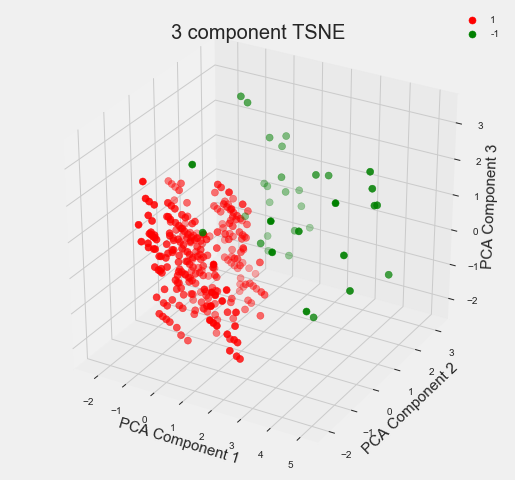

In [293]:
from mpl_toolkits.mplot3d import axes3d
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax = fig.gca(projection='3d')
ax.set_xlabel('PCA Component 1', fontsize = 15)
ax.set_ylabel('PCA Component 2', fontsize = 15)
ax.set_zlabel('PCA Component 3', fontsize = 15)
ax.set_title('3 component TSNE', fontsize = 20)
targets = [1,-1]
colors = ['r', 'g']
for target, color in zip(targets,colors):
    indicesToKeep = pcaDf['Label'] == target
    ax.scatter(pcaDf.loc[indicesToKeep, 'P1']
               , pcaDf.loc[indicesToKeep, 'P2']
               , pcaDf.loc[indicesToKeep, 'P3']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()
plt.show()

In [294]:
pca = PCA(n_components=2)  # Reduce to k=3 dimensions
scaler = StandardScaler()
#normalize the metrics
temp_df=occupancy_df.drop(['timestamp','value_x','value_y'], axis=1)
X = scaler.fit_transform(temp_df)
X_reduce = pca.fit_transform(X)
pcaDf = pd.DataFrame(data = X_reduce, columns = ['P1', 'P2'])
pcaDf['Label']=occupancy_df['anomaly'].values

# Anamolies detected for Occuapancy of traffic datset

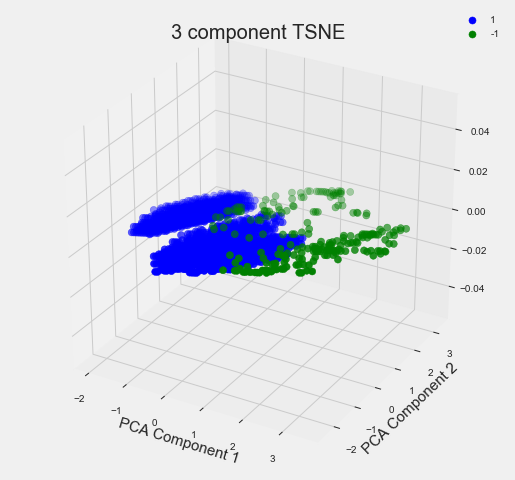

In [295]:
from mpl_toolkits.mplot3d import axes3d
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax = fig.gca(projection='3d')
ax.set_xlabel('PCA Component 1', fontsize = 15)
ax.set_ylabel('PCA Component 2', fontsize = 15)
ax.set_title('3 component TSNE', fontsize = 20)
targets = [1,-1]
colors = ['b', 'g']
for target, color in zip(targets,colors):
    indicesToKeep = pcaDf['Label'] == target
    ax.scatter(pcaDf.loc[indicesToKeep, 'P1']
               , pcaDf.loc[indicesToKeep, 'P2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()
plt.show()

In [296]:
pca = PCA(n_components=2)  # Reduce to k=3 dimensions
scaler = StandardScaler()
#normalize the metrics
temp_df=speed_df.drop(['timestamp','value_x','value_y'], axis=1)
X = scaler.fit_transform(temp_df)
X_reduce = pca.fit_transform(X)
pcaDf = pd.DataFrame(data = X_reduce, columns = ['P1', 'P2'])
pcaDf['Label']=speed_df['anomaly'].values

# Anamolies detected for Speed of traffic datset

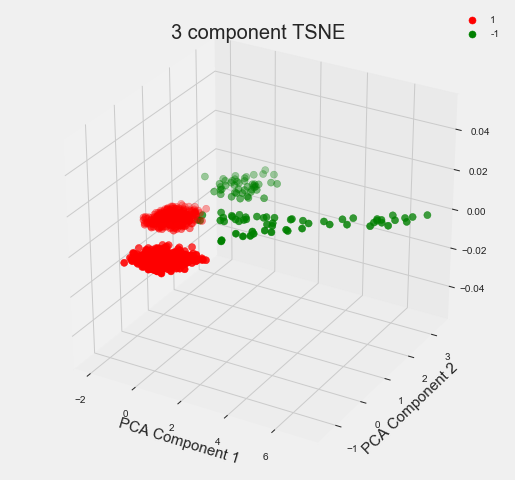

In [297]:
from mpl_toolkits.mplot3d import axes3d
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(1,1,1) 
ax = fig.gca(projection='3d')
ax.set_xlabel('PCA Component 1', fontsize = 15)
ax.set_ylabel('PCA Component 2', fontsize = 15)
ax.set_title('3 component TSNE', fontsize = 20)
targets = [1,-1]
colors = ['r', 'g']
for target, color in zip(targets,colors):
    indicesToKeep = pcaDf['Label'] == target
    ax.scatter(pcaDf.loc[indicesToKeep, 'P1']
               , pcaDf.loc[indicesToKeep, 'P2']
               , c = color
               , s = 50)
ax.legend(targets)
ax.grid()
plt.show()

# In the above all -1's are Anamolies, where we can see the divided and detected anamolies in the data after the application of Isolation Forest